In [1]:
'''
Process the XRD data for the quaternary samples.
'''
import numpy as np
import matplotlib.pyplot as plt
from pyhtp.xrd import XrdDatabase, ICSD
from pyhtp.typing import SampleInfo, AngleRange
from pyhtp.quaternary import scatter_quaternary

icsd = ICSD(file_dir='data/GSST ICSD')
sample2 = SampleInfo(
    name='GSTSe-2', element=['Se', 'Sb', 'Ge', 'Te'],
    angle_range=AngleRange(28, 52), temperature=300,
    film_thickness=[12.4, 7.6, 12.4, 7.6])
db2_original = XrdDatabase(file_dir='data/GSTSe_XRD/GSTSe-2-300', info=sample2)
sample1 = SampleInfo(
    name='GSTSe-2', element=['Se', 'Sb', 'Ge', 'Te'],
    angle_range=AngleRange(28, 52), temperature=350,
    film_thickness=[12.4, 7.6, 12.4, 7.6])
db1_original = XrdDatabase(file_dir='data/GSTSe_XRD/GSTSe-2-350', info=sample1)

0.004999999888241285
100.00000223517435


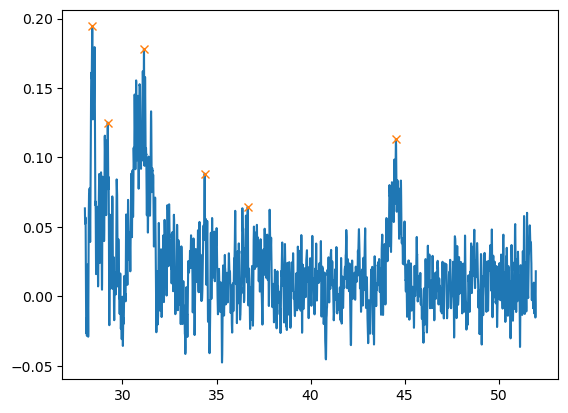

In [57]:
from scipy.signal import find_peaks

sample = db1_original.data[330]
fig, ax = plt.subplots()
sample = sample.subtract_baseline(lam=700).smooth(window=13, factor=0)
print(np.mean(np.diff(sample.two_theta)))
print(0.5 / np.mean(np.diff(sample.two_theta)))
peak_index, properties = find_peaks(sample.intensity, height=0.0, distance=100, prominence=0.1)
ax.plot(sample.two_theta, sample.intensity)
ax.plot(sample.two_theta[peak_index], sample.intensity[peak_index], 'x')

In [2]:
db1 = db1_original.subtract_baseline(lam=500).smooth(window=101, factor=0.6)

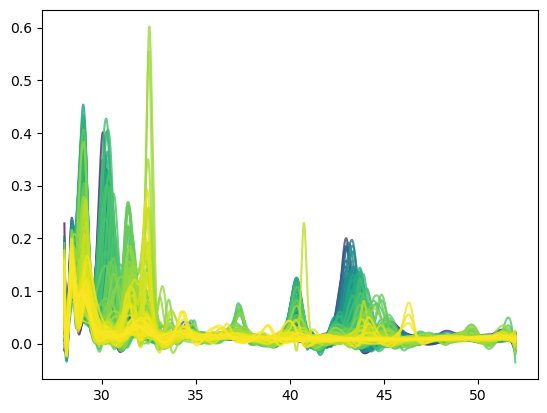

In [3]:
db1.plot()

In [8]:
tolerance = 0.5  # degree
ch_peaks = db1.characteristic_peak(height=0.05)
ch_peaks = np.array(ch_peaks)
peak_angles = []
for pattern in db1.data:
    _, properties = pattern.get_peak(height=0.05)
    peak_angles.append(properties['peak_angles'])
encoded_data = np.zeros((len(peak_angles), len(ch_peaks)))
for i, angles in enumerate(peak_angles):
    for j, peak in enumerate(ch_peaks):
        # Calculate the nearest peak in angles to the specific ch_peak
        nearest_index = np.argmin(np.abs(angles - peak))
        # If the difference is too large, set 0
        if np.abs(angles[nearest_index] - peak) > tolerance:
            encoded_data[i, j] = 0
            continue
        encoded_data[i, j] = 1 - np.abs(angles[nearest_index] - peak) / peak


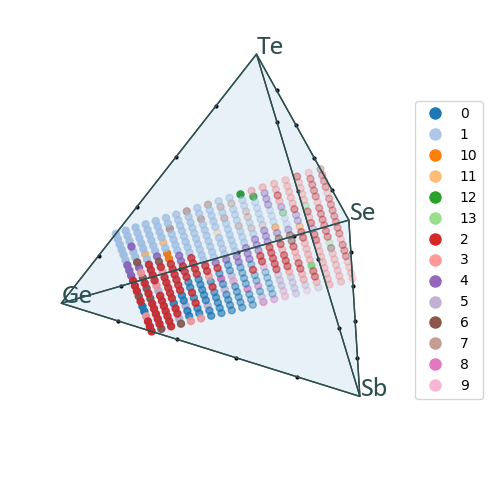

The best silhouette score is 0.9756688493864086


In [9]:
# K-means clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []
scores = []
for k in range(2, 15):
    kmeans = KMeans(
        n_clusters=k,
        random_state=0,
        verbose=0)
    result = kmeans.fit_predict(encoded_data)
    score = silhouette_score(encoded_data, result)
    results.append(result)
    scores.append(score)
# Get the best result
best_index = np.argmax(scores)
label = results[best_index]
scatter_quaternary(
    value=label, label=('Ge', 'Sb', 'Se', 'Te'),
    database=db1, ticknum=5, path_type='snakelike')
print('The best silhouette score is', scores[best_index])

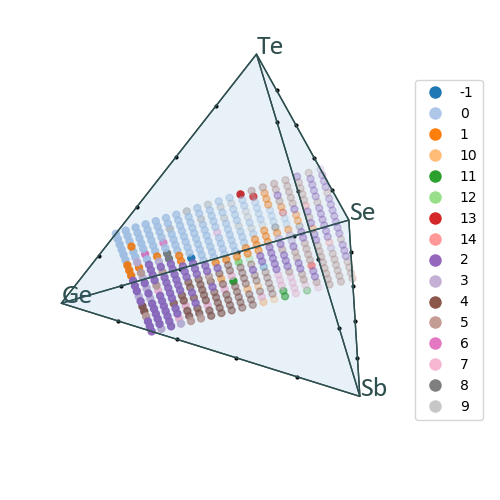

The best silhouette score is 0.9887409558649868


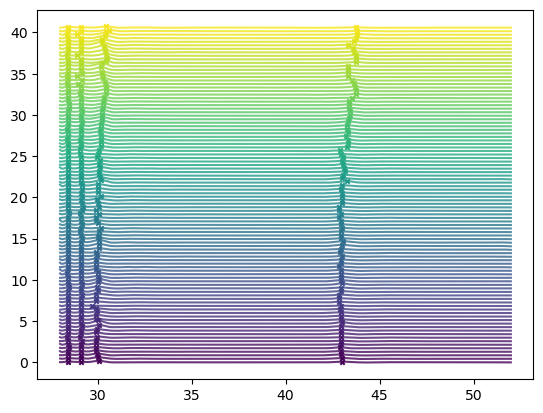

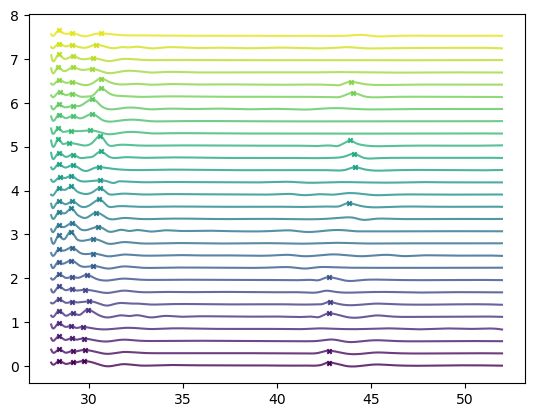

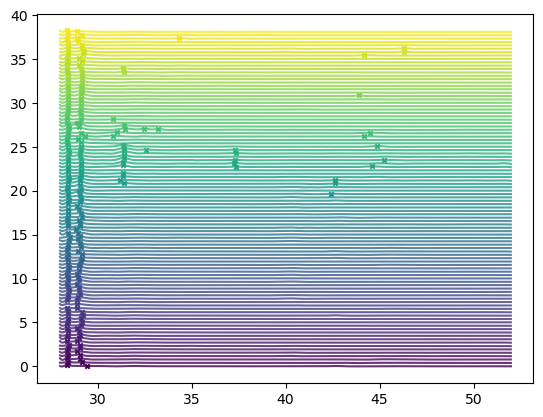

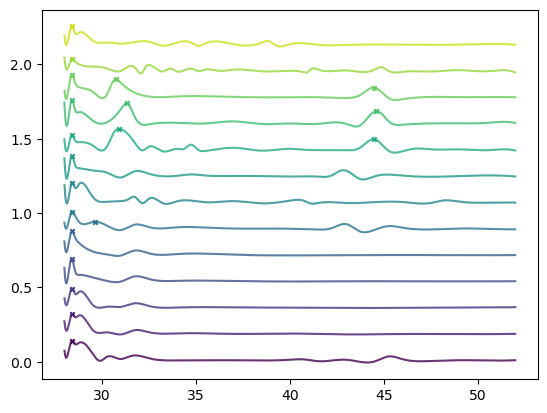

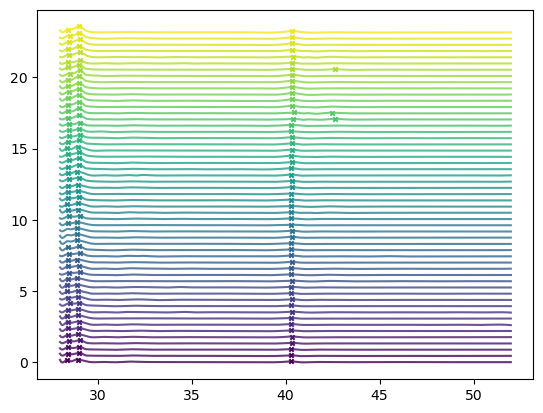

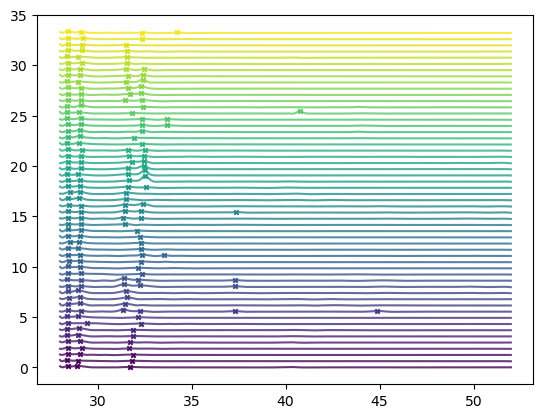

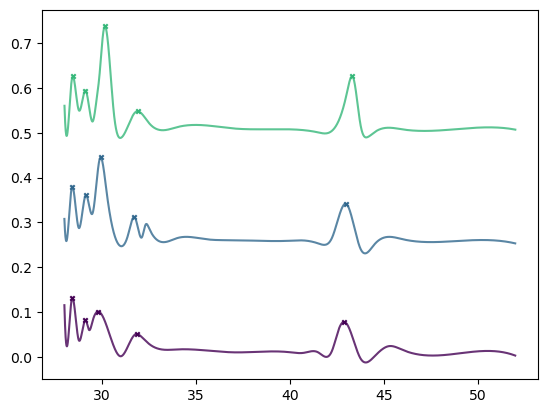

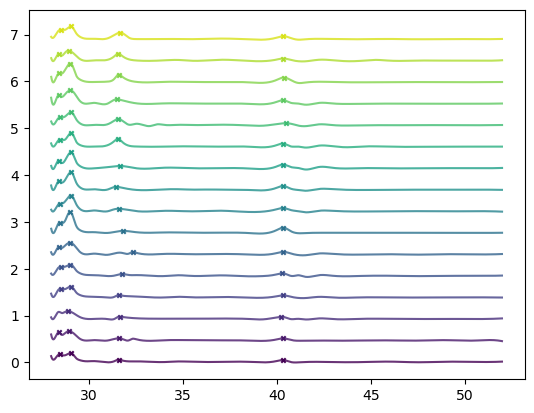

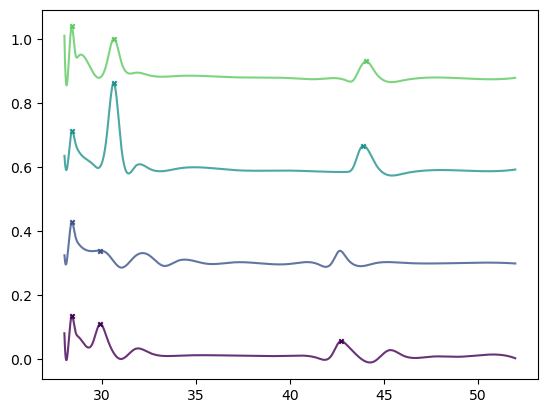

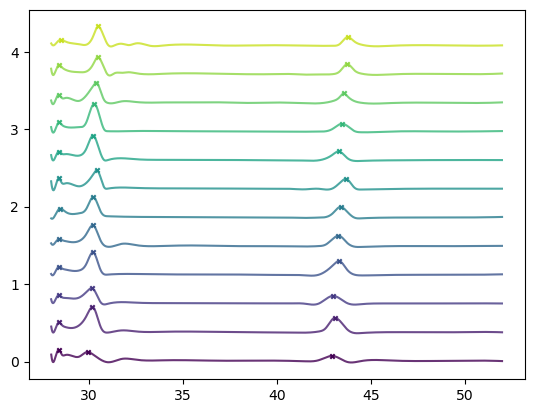

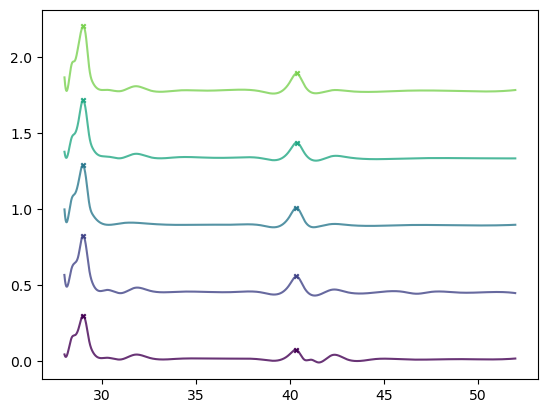

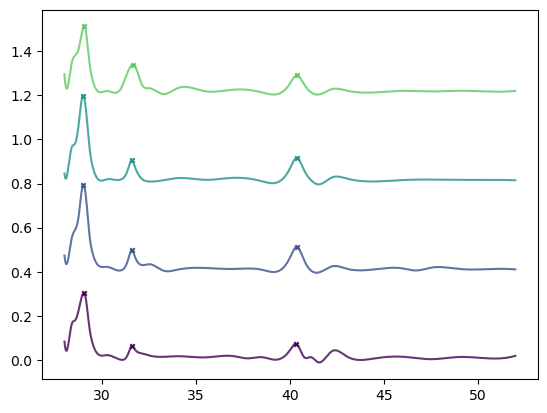

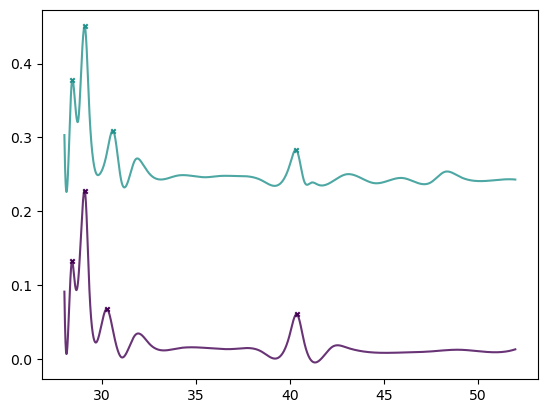

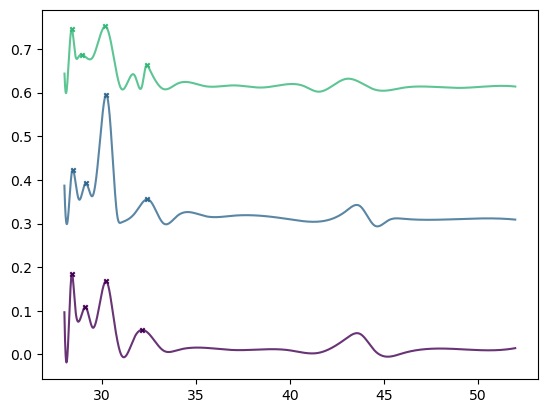

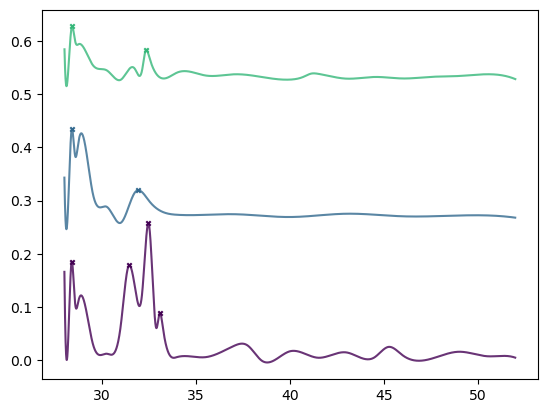

In [10]:
# DBSCAN clustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

results = []
scores = []
for eps in np.linspace(0.05, 0.2, 20):
    for min_cluster_size in range(2, 10):
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_cluster_size)
        result = dbscan.fit_predict(encoded_data)
        score = silhouette_score(encoded_data, result)
        results.append(result)
        scores.append(score)
# Get the best result
best_index = np.argmax(scores)
label = results[best_index]
scatter_quaternary(
    value=label, label=('Ge', 'Sb', 'Se', 'Te'),
    database=db1, ticknum=5, path_type='snakelike')
print('The best silhouette score is', scores[best_index])
for i in range(max(label) + 1):
    fig, ax = plt.subplots()
    # Get all the points index where label is i
    index = np.where(label == i)[0].tolist()
    db1.plot(ax=ax, index=index, style='stack', height=0.05)

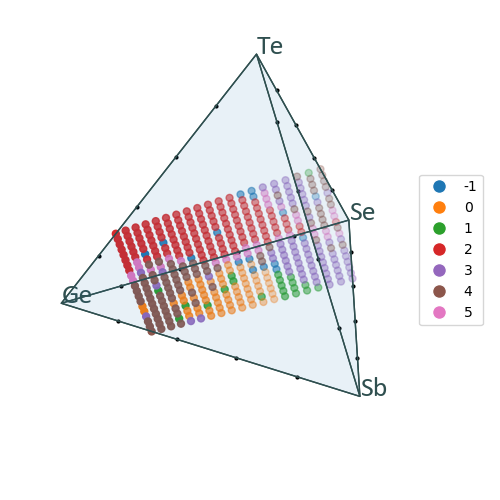

The best silhouette score is 0.9234304438251919


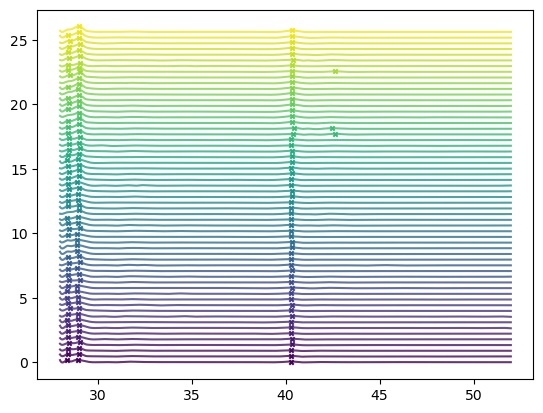

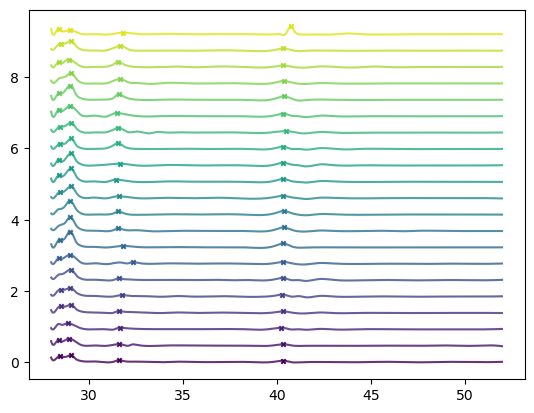

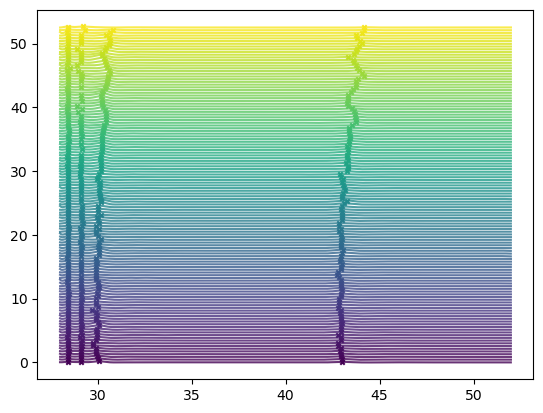

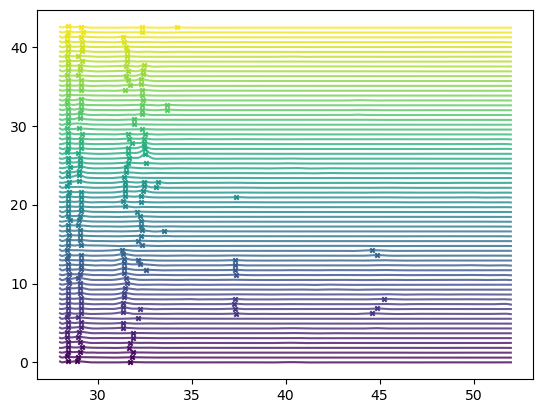

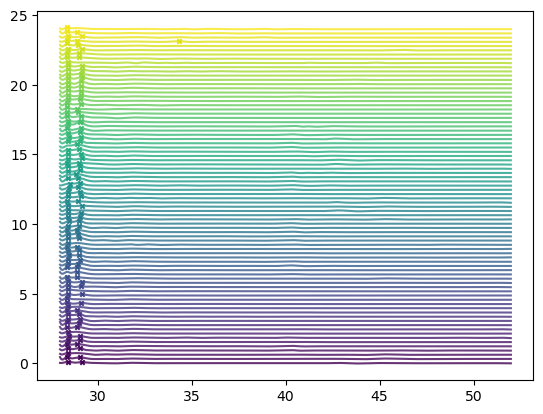

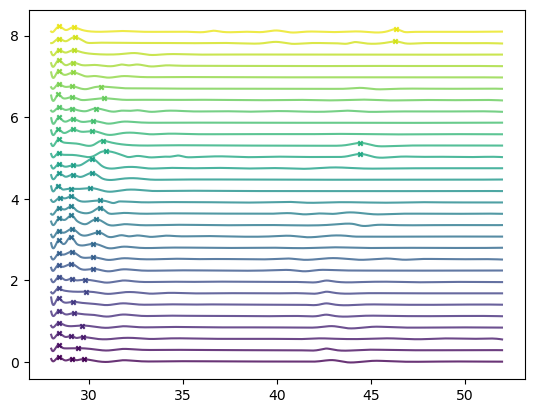

In [7]:
# HDBSCAN clustering
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score

results = []
scores = []
for min_cluster_size in range(2, 15):
    hdbscan = HDBSCAN(
        min_cluster_size=min_cluster_size)
    result = hdbscan.fit_predict(encoded_data)
    score = silhouette_score(encoded_data, result)
    results.append(result)
    scores.append(score)
# Get the best result
best_index = np.argmax(scores)
label = results[best_index]
scatter_quaternary(
    value=label, label=('Ge', 'Sb', 'Se', 'Te'),
    database=db1, ticknum=5, path_type='snakelike')
print('The best silhouette score is', scores[best_index])
for i in range(max(label) + 1):
    fig, ax = plt.subplots()
    # Get all the points index where label is i
    index = np.where(label == i)[0].tolist()
    db1.plot(ax=ax, index=index, style='stack', height=0.05)